In [4]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import mlflow
from pathlib import Path


In [5]:
df = pd.read_csv("../../data/data_for_model.csv")
# we cannot have NaNs in the target variable
df = df.dropna(subset=["log_total_price_eur"])
print(f"We have {len(df)} data points for our model")
df.head()

We have 5343 data points for our model


,hash_id,neighbourhood,total_price_eur,price_m2_eur,price_m2_bgn,size_m2,nr_of_rooms,appartment_floor,total_floors,is_first_floor,is_last_floor,near_public_transport,furnished,includes_parking,new_building,akt16,broker_commision,log_total_price_eur
0,ca420156d8e9fbfbd273afed51b5b294de1496404facea...,Овча Купел,92512.0,1888.0,3692.13,49.0,1.0,1.0,0,6.0,1,1,0,1,0,1.0,1.0,11.435094
1,528685330d09ed04f6d4182b1b75bff4340766ce5aac35...,Фондови Жилища,95975.0,1745.0,3413.81,55.0,1.0,2.0,0,3.0,0,1,1,0,0,1.0,1.0,11.471843
2,b6c286ce2e6de97589316b15c742cce2b09e5b655ba169...,Левски,98022.0,1581.0,3091.47,62.0,2.0,3.0,0,5.0,0,1,0,0,0,1.0,1.0,11.492947
3,9a0fa18467acc9749700e245657c32afdf868653c06d87...,Карпузица,98560.0,2240.0,4380.08,44.0,2.0,NaN,0,NaN,0,1,1,0,0,NaN,1.0,11.498421
4,d4bc76fbc196bf3af9ccb2d2caae76b3b17f5980083ba3...,Левски,98616.0,1761.0,3443.48,56.0,2.0,1.0,0,6.0,1,0,1,0,0,1.0,1.0,11.498989


In [6]:
# Define the preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder

numeric_features = ["size_m2", "nr_of_rooms", "total_floors", "appartment_floor"]
categorical_features = ["neighbourhood"]
boolean_features = ["is_first_floor", "is_last_floor", "includes_parking", "near_public_transport", "furnished", 
                    "new_building", "akt16"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", TargetEncoder(), categorical_features),
    ("bool", SimpleImputer(strategy="most_frequent"), boolean_features)
])

In [7]:
mlruns_path = Path("../../mlruns").resolve()

mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment("real-estate-price-prediction")
# log_models=False — we log the best model explicitly below to avoid duplicates
mlflow.sklearn.autolog(log_models=False)


What autolog gives you automatically:
- All hyperparameters of the estimator (including the best params from GridSearch)
- Training metrics (sklearn's default scorer)
- The fitted model artifact
- Feature names, sklearn version, tags

In [9]:
from sklearn.model_selection import KFold

feature_cols = numeric_features + categorical_features + boolean_features
target_col = "log_total_price_eur"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dtr = DecisionTreeRegressor(random_state=42)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", dtr)
])

param_grid = {
    "model__max_depth": [8, 10, 20, 30],
    "model__min_samples_leaf": [15, 20, 30, 60]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search_cv = GridSearchCV(estimator=pipeline,
                              param_grid=param_grid,
                              cv=cv,
                              scoring="neg_root_mean_squared_error",
                              refit=True)

with mlflow.start_run(run_name="GridSearchCV_DecisionTrees"):
    grid_search_cv.fit(X_train, y_train)

    best = grid_search_cv.best_estimator_
    y_pred = best.predict(X_test)

    test_mae  = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2   = r2_score(y_test, y_pred)

    mlflow.log_params({
        "best_max_depth":        grid_search_cv.best_params_["model__max_depth"],
        "best_min_samples_leaf": grid_search_cv.best_params_["model__min_samples_leaf"],
        "cv_n_splits":           cv.n_splits,
        "test_size":             0.2,
    })

    mlflow.log_metric("cv_best_RMSE", -grid_search_cv.best_score_)
    mlflow.log_metrics({
        "test_MAE":  test_mae,
        "test_RMSE": test_rmse,
        "test_R2":   test_r2,
    })

    # MLflow 3.x: log_model returns a LoggedModel with a model_uri
    logged_model = mlflow.sklearn.log_model(best, name="best_model")
    # Store the URI as a tag so the loading cell can find it directly
    mlflow.set_tag("model_uri", logged_model.model_uri)

print("Best parameters: ", grid_search_cv.best_params_)
print(f"CV best RMSE : {-grid_search_cv.best_score_:.4f}")
print(f"\n=== Test Set ===")
print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")


2026/04/30 16:28:04 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\venvs\datasci\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/30 16:28:07 INFO mlflow.sklearn.utils: Logging the 5 best runs, 11 runs will be omitted.
2026/04/30 16:28:07 WARNING mlflow.utils.autologging_utils: MLflow au

🏃 View run marvelous-pig-381 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/f4d3a17f3a9d410780899f72e6b00a7b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run smiling-horse-453 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/9796a39b0794452faa66c81de9c04f74
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run vaunted-fish-533 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/dd97aefad995445db50fe56c43298fff
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run tasteful-seal-135 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/9310de9bb085459b8f71f981f46d1a8c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run popular-swan-297 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/46738051d83744eab2ac52579671bbc3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640

2026/04/30 16:28:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run GridSearchCV_DecisionTrees at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/8039e526eb604e39a1eef5bf277a6f42
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
Best parameters:  {'model__max_depth': 10, 'model__min_samples_leaf': 20}
CV best RMSE : 0.2048

=== Test Set ===
MAE  : 0.1355
RMSE : 0.1925
R²   : 0.5802


In [52]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000/")

client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name("real-estate-price-prediction")

if experiment is None:
    raise RuntimeError("Experiment not found. Is the MLflow server running?")

# Find the best run (lowest test_RMSE) that has a 'model_uri' tag
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.model_uri != ''",
    order_by=["metrics.test_RMSE ASC"],
)

if not runs:
    raise RuntimeError(
        "No run with a 'model_uri' tag found.\n"
        "Re-run the training cell — it stores the model URI as a tag."
    )

best_run = runs[0]
model_uri = best_run.data.tags["model_uri"]

print(f"Loading: {best_run.info.run_name}")
print(f"test_RMSE: {best_run.data.metrics.get('test_RMSE', 'N/A')}")
print(f"model_uri: {model_uri}")

model = mlflow.sklearn.load_model(model_uri)
print("Model loaded:", model)


Loading: GridSearchCV_DecisionTrees
test_RMSE: 0.192518502137501
model_uri: models:/m-36e905da1dc64b0aa25e0a53dc55331a


Model loaded: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['size_m2', 'nr_of_rooms',
                                                   'total_floors',
                                                   'appartment_floor']),
                                                 ('cat', TargetEncoder(),
                                                  ['neighbourhood']),
                                                 ('bool',
                                                  SimpleImputer(strategy='most_frequent'),
                                         

In [26]:
import numpy as np

# One or more rows — must be a DataFrame with the same column names as feature_cols
# Column order does NOT matter; ColumnTransformer selects by name
sample = pd.DataFrame([{
    "size_m2":               50,
    "nr_of_rooms":           1,
    "total_floors":          8,
    "appartment_floor":      8,
    "neighbourhood":         "Люлин 3",   # must be a value seen during training
    "is_first_floor":        0,
    "is_last_floor":         0,
    "includes_parking":      0,
    "near_public_transport": 0,
    "furnished":             0,
    "new_building":          0,
    "akt16":                 0,
}])

log_price_pred = grid_search_cv.best_estimator_.predict(sample)[0]
price_eur_pred = np.exp(log_price_pred)   # reverse the log transform

print(f"Predicted log price : {log_price_pred:.4f}")
print(f"Predicted price     : €{price_eur_pred:,.0f}")

Predicted log price : 11.6298
Predicted price     : €112,398


In [16]:
import shap

# Extract the fitted preprocessor and tree from the pipeline
preprocessor_fitted = grid_search_cv.best_estimator_.named_steps["preprocessor"]
tree_model          = grid_search_cv.best_estimator_.named_steps["model"]

# Transform to numeric arrays — SHAP cannot handle raw string columns
X_train_t = preprocessor_fitted.transform(X_train)
X_test_t  = preprocessor_fitted.transform(X_test)

# Feature names after ColumnTransformer (num + cat + bool, in definition order)
transformed_feature_names = numeric_features + categorical_features + boolean_features

# TreeExplainer is exact and fast for decision trees
explainer   = shap.TreeExplainer(tree_model, data=X_train_t)
shap_values = explainer(X_test_t[:200])
shap_values.feature_names = transformed_feature_names

print("SHAP values computed:", shap_values.shape)


SHAP values computed: (200, 12)


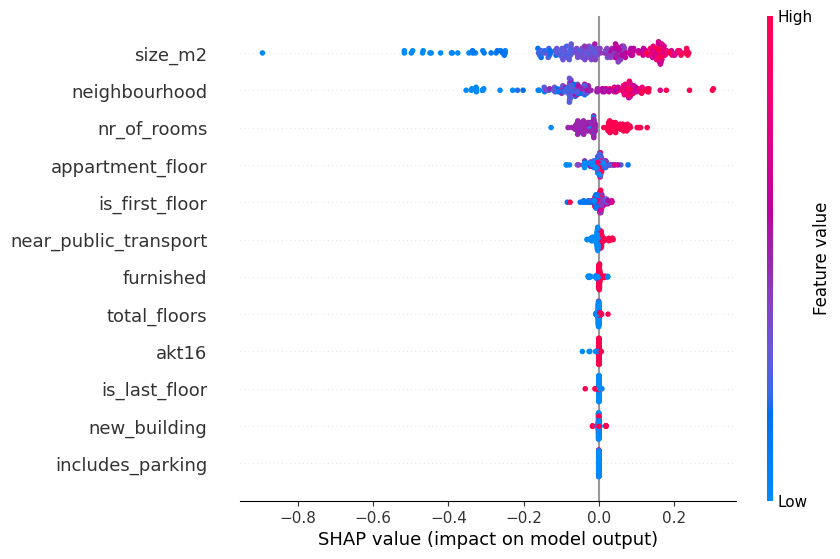

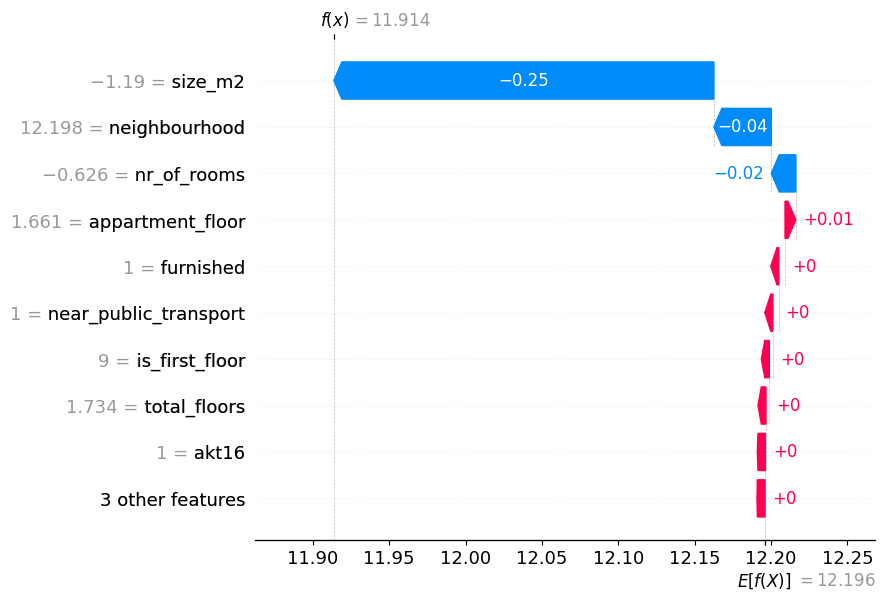

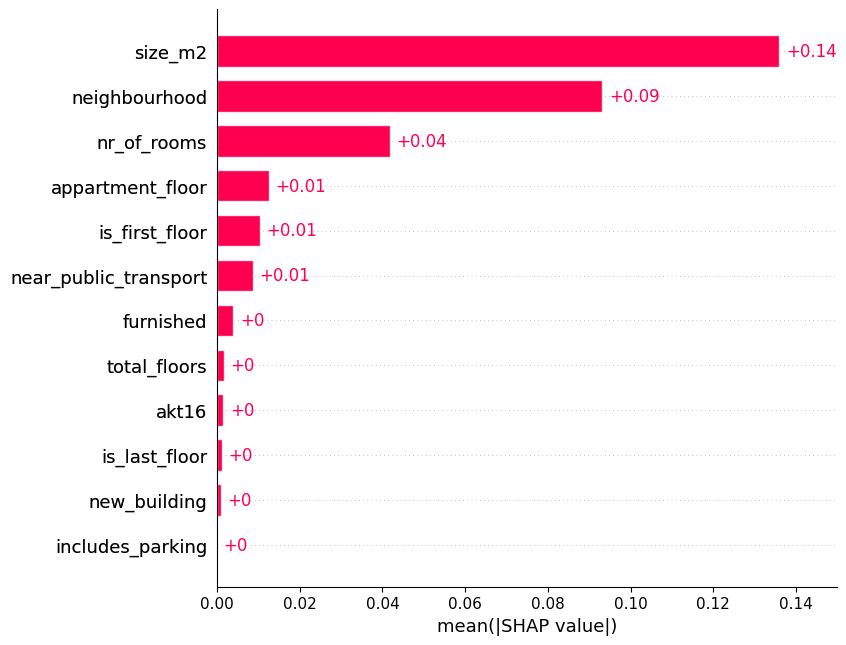

In [17]:
import matplotlib.pyplot as plt

# --- Beeswarm: feature importance + direction across all explained samples ---
shap.plots.beeswarm(shap_values, max_display=12)

# --- Waterfall: breakdown for a single prediction (first test row) ---
shap.plots.waterfall(shap_values[0])

# --- Bar: mean |SHAP| per feature (global importance) ---
shap.plots.bar(shap_values, max_display=12)


## Imbalanced binary features — diagnosis and fixes

When a binary feature has a very skewed distribution (e.g. 84% / 16%), a decision tree rarely splits on it because most leaves contain almost no minority-class rows → the split gives tiny information gain.

**Why oversampling rows is the wrong fix here:**
Oversampling is the right tool when the *target variable* is imbalanced (e.g. fraud detection: 99% non-fraud). For a *feature* imbalance in regression, duplicating rows distorts the training distribution without any principled justification.

**Why interaction features (`parking × size_m2`) introduce problems:**
When `parking=1`, the interaction term equals `size_m2` exactly — perfectly correlated. For a tree this just creates a competing feature for the same split and dilutes SHAP attribution for `size_m2`.

**The right fix: sample weights**

Sample weights don't change the data at all. They change how much each row contributes to the loss during training:

$$\text{MSE}_\text{weighted} = \frac{\sum_i w_i \cdot (y_i - \hat{y}_i)^2}{\sum_i w_i}$$

A parking=1 row with `w=6.25` means its prediction error counts **6.25× more** toward the total loss. The tree therefore has a much stronger incentive to find splits that correctly predict those rows — i.e., it's more likely to split on `includes_parking`.

We use **inverse-frequency weighting**: $w_i = \frac{1}{P(\text{class of } x_i)}$, so rare rows get high weight and common rows get low weight. The weighted sum equals the original dataset size, so the scale of the loss is preserved.

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- Step 1: Verify the raw signal ---
# Check mean price (EUR) for each imbalanced binary feature (split at 0/1)
bool_features_check = ["includes_parking", "near_public_transport", "furnished",
                        "new_building", "akt16", "is_first_floor", "is_last_floor"]

df_eda = df.copy()
df_eda["price_eur"] = np.exp(df_eda["log_total_price_eur"])

print(f"{'Feature':<25} {'False (0) — mean €':>20} {'True (1) — mean €':>20} {'Count 0':>8} {'Count 1':>8} {'Δ%':>8}")
print("-" * 95)
for feat in bool_features_check:
    g = df_eda.groupby(feat)["price_eur"].agg(["mean", "count"])
    mean0, n0 = g.loc[0, "mean"], g.loc[0, "count"]
    mean1, n1 = g.loc[1, "mean"], g.loc[1, "count"]
    delta_pct = (mean1 - mean0) / mean0 * 100
    print(f"{feat:<25} {mean0:>20,.0f} {mean1:>20,.0f} {n0:>8,} {n1:>8,} {delta_pct:>+7.1f}%")


Feature                     False (0) — mean €    True (1) — mean €  Count 0  Count 1       Δ%
-----------------------------------------------------------------------------------------------
includes_parking                       201,536              220,742    4,482      861    +9.5%
near_public_transport                  206,565              202,425    2,847    2,496    -2.0%
furnished                              206,771              204,059    1,127    4,216    -1.3%
new_building                           202,657              210,968    4,074    1,269    +4.1%
akt16                                  211,961              203,848      740    4,229    -3.8%
is_first_floor                         189,135              179,963       22       23    -4.8%
is_last_floor                          206,885              192,445    4,509      834    -7.0%


d:\venvs\datasci\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 7 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
d:\venvs\datasci\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 10 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
d:\venvs\datasci\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column

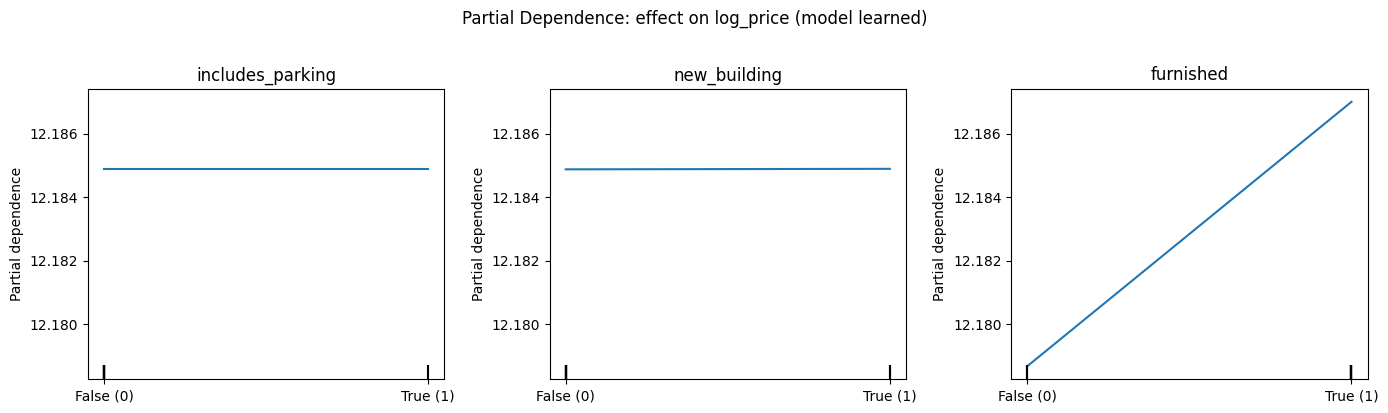

In [62]:
from sklearn.inspection import PartialDependenceDisplay

# --- Step 2: Partial Dependence Plot — what did the model actually learn? ---
# Uses the trained pipeline directly on raw features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
features_to_check = ["includes_parking", "new_building", "furnished"]
PartialDependenceDisplay.from_estimator(
    model, X_train,
    features=features_to_check,
    ax=axes,
    kind="average",
)
for ax, feat in zip(axes, features_to_check):
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.xaxis.set_major_locator(mticker.FixedLocator([0, 1]))
    ax.set_xticklabels(["False (0)", "True (1)"])
plt.suptitle("Partial Dependence: effect on log_price (model learned)", y=1.02)
plt.tight_layout()
plt.show()


### Adding the additonal sample weigth to has_parking variable
This will make points where parking==True count more towards the loss/MSE.

In [11]:
import numpy as np

# --- Note on interaction terms for Decision Trees ---
# parking_x_size = includes_parking * size_m2 is perfectly correlated with
# size_m2 when parking=1. For linear models this adds a genuine new degree of
# freedom (β_interaction). For trees it just creates a competing feature for the
# same split — and dilutes SHAP values for size_m2.
#
# The principled fix for trees is sample_weight only: no new features,
# no collinearity, no distributional distortion.

# --- Sample weights: inverse-frequency weighting ---
# Rows where includes_parking=1 are rare (16%) so the tree almost never splits
# on that signal. Upweighting them makes those splits contribute more to the loss.
# The training distribution is preserved — only the loss contribution changes.

p_parking = X_train["includes_parking"].mean()
w_majority = 1 / (1 - p_parking)   # weight for parking=0 rows
w_minority = 1 / p_parking          # weight for parking=1 rows (~6×)

sample_weights = X_train["includes_parking"].apply(
    lambda v: w_minority if v == 1 else w_majority
).values

print(f"parking=0 weight : {w_majority:.3f}")
print(f"parking=1 weight : {w_minority:.3f}  (ratio: {w_minority/w_majority:.1f}×)")
print(f"Weighted sum check: {sample_weights.sum():.0f}  (should ≈ {len(sample_weights):.0f})")


parking=0 weight : 1.187
parking=1 weight : 6.341  (ratio: 5.3×)
Weighted sum check: 8548  (should ≈ 4274)


In [19]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import shap

# Reuse the original pipeline — no feature changes, just pass sample_weight
# GridSearchCV propagates fit_params to each fold's estimator.fit() call
cv = KFold(n_splits=5, shuffle=True, random_state=42)
gs_weighted = GridSearchCV(
    Pipeline([("preprocessor", preprocessor),
              ("model", DecisionTreeRegressor(random_state=42))]),
    param_grid={"model__max_depth": [8, 10, 15, 20],
                "model__min_samples_leaf": [5, 10, 15, 20]},
    cv=cv, scoring="neg_root_mean_squared_error", refit=True
)

with mlflow.start_run(run_name="GridSearchCV_DecisionTrees_Weighted"):

    gs_weighted.fit(X_train, y_train, model__sample_weight=sample_weights)

    best_w   = gs_weighted.best_estimator_
    y_pred_w = best_w.predict(X_test)
    rmse_baseline = np.sqrt(mean_squared_error(y_test, grid_search_cv.best_estimator_.predict(X_test)))
    rmse_weighted = np.sqrt(mean_squared_error(y_test, y_pred_w))

print("=== Sample-weighted model ===")
print(f"Best params  : {gs_weighted.best_params_}")
print(f"Test RMSE    : {rmse_weighted:.4f}  (baseline: {rmse_baseline:.4f})")
print(f"Test R²      : {r2_score(y_test, y_pred_w):.4f}")

# SHAP — same features, no collinearity concern, clean comparison
prep_w  = best_w.named_steps["preprocessor"]
tree_w  = best_w.named_steps["model"]
Xtr_t_w = prep_w.transform(X_train)
Xte_t_w = prep_w.transform(X_test)

explainer_w   = shap.TreeExplainer(tree_w, data=Xtr_t_w)
shap_values_w = explainer_w(Xte_t_w[:200])
shap_values_w.feature_names = feature_cols

print("\n=== SHAP importance: baseline vs sample-weighted ===")
base_imp = dict(zip(feature_cols, np.abs(shap_values.values).mean(axis=0)))
w_imp    = dict(zip(feature_cols, np.abs(shap_values_w.values).mean(axis=0)))

print(f"{'Feature':<30} {'Baseline':>10} {'Weighted':>10}  {'Δ':>6}")
print("-" * 62)
for feat in feature_cols:
    b, w = base_imp[feat], w_imp[feat]
    delta = w - b
    arrow = " ↑" if delta > 0.001 else (" ↓" if delta < -0.001 else "  ")
    print(f"{feat:<30} {b:>10.4f} {w:>10.4f}  {delta:>+6.4f}{arrow}")


2026/04/30 16:48:02 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\venvs\datasci\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/30 16:48:06 INFO mlflow.sklearn.utils: Logging the 5 best runs, 11 runs will be omitted.
2026/04/30 16:48:06 WARNING mlflow.utils.autologging_utils: MLflow au

🏃 View run treasured-pug-856 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/71373ed17a044ae3b7dcf92d1362798e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run nosy-gull-212 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/bd6cafe5502747178e67d6cb24fe933e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run mercurial-wasp-979 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/b46893277f8342f99df36a31ef1522b6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run bustling-turtle-43 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/bfa4505e69bb4354b529cae58b39e2a8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run sassy-fowl-673 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/a0aa3eb871604592a69b6fac3b0683e0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378

In [20]:
df[["includes_parking", "new_building", "size_m2"]].groupby("includes_parking").mean()

,new_building,size_m2
includes_parking,,
0,0.186301,85.767068
1,0.504065,95.097561


This strongly confirms the hypothesis, primarily through new_building:

new_building: 18.6% vs 50.4%
Parking=1 apartments are 2.7× more likely to be new buildings. This is the dominant effect. When the tree splits on new_building=1, it's already capturing a large chunk of the parking signal — new buildings are expensive and come with parking. After that split, parking adds very little incremental information.

size_m2: 85.8m² vs 95.1m²
Only a ~10% difference, so size is a weaker proxy. It contributes some absorption but is not the main driver.

The conclusion: includes_parking is largely a consequence of new_building, not an independent price driver. The tree's splits on new_building (and to a lesser extent size_m2) already route parking=1 rows into high-price leaves. By the time the tree would consider splitting on includes_parking, the within-leaf variance it could explain is small.

This also explains why the sample weights didn't help — you upweighted the parking=1 rows, but those rows are already well-predicted (they're mostly new buildings, and the model handles new buildings well). The weights added emphasis where the model was already accurate, not where it was struggling.

### Random Forest Regression

In [29]:
from sklearn.ensemble import RandomForestRegressor

params_grid = {
    "rf_model__n_estimators": [20, 40, 80, 160],
    "rf_model__max_depth": [10, 20, 40, 80],
    "rf_model__min_samples_leaf": [5, 10, 20, 40]
}

rf = RandomForestRegressor()
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search_rf = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("rf_model", rf)]),
    params_grid,
    cv=cv,
    scoring = "neg_root_mean_squared_error"
)

with mlflow.start_run(run_name="RandomForest"):
    grid_search_rf.fit(X_train, y_train)
    y_pred = grid_search_rf.best_estimator_.predict(X_test)

    test_mae = mean_absolute_error(y_pred, y_test)
    test_rmse = np.sqrt(mean_squared_error(y_pred, y_test))

print("=== Random Forest model ===")
print(f"Best params  : {grid_search_rf.best_params_}")
print(f"Test RMSE    : {test_rmse:.4f}")
print(f"Test R²      : {r2_score(y_test, y_pred):.4f}")


2026/04/30 17:19:47 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\venvs\datasci\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/30 17:22:12 INFO mlflow.sklearn.utils: Logging the 5 best runs, 59 runs will be omitted.
2026/04/30 17:22:12 WARNING mlflow.utils.autologging_utils: MLflow au

2026/04/30 17:19:47 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\venvs\datasci\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/30 17:22:12 INFO mlflow.sklearn.utils: Logging the 5 best runs, 59 runs will be omitted.
2026/04/30 17:22:12 WARNING mlflow.utils.autologging_utils: MLflow au

🏃 View run thundering-skunk-702 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/88d70d27890c4fa5b6f8ca9808ff35a4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run gentle-ant-166 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/f187fc75e0b24f59a04147c82d5ea901
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run wise-sponge-915 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/fddc16b424ed4f918ab3a70f35d2d90a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run adventurous-bat-471 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/8260586cc4d446769b761f321b0be5b9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run debonair-pug-891 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/6bd20fbc486a4edd8f04efebdc86ecd8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/75964

combining different models in a single run <br>
We will create experiments for different models and each will have sub-runs

In [33]:
import xgboost as xgb

xgboost = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
dtr = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)
cv = KFold(n_splits=5)

experiments = [
    {
    "run_name": "XGBoost",
    "pipeline": Pipeline([("preprocessor", preprocessor), ("model", xgboost)]), 
    "param_grid": {
        "model__n_estimators": [10, 20],
        "model__max_depth": [5, 10], 
        "model__learning_rate": [0.01, 0.1, 0.2],
        "model__colsample_bytree": [0.8, 1]
        },
    },

    {
    "run_name": "DecisionTreeRegressor",
    "pipeline": Pipeline([("preprocessor", preprocessor), ("model", dtr)]), 
    "param_grid": {
        "model__max_depth": [5, 10], 
        "model__min_samples_leaf": [10, 20]
        },
    },

    {
    "run_name": "RandomForestRegressor",
    "pipeline": Pipeline([("preprocessor", preprocessor), ("model", rf)]), 
    "param_grid": {
        "model__n_estimators": [10, 20],
        "model__max_depth": [5, 10], 
        "model__min_samples_leaf": [10, 20]
        },
    }
]

for exp in experiments:
    grid_search = GridSearchCV(exp["pipeline"], 
                               exp["param_grid"], 
                               cv=cv, 
                               scoring="neg_root_mean_squared_error")
    
    # param_suffix = "_".join(f"{k.split('__')[-1]}={v}" for k, v in grid_search.best_params_.items())
    # run_name = f"{exp['run_name']}_{param_suffix}"  # e.g. "RandomForest_n_estimators=80_max_depth=10"

    with mlflow.start_run(run_name=exp["run_name"]):
        grid_search.fit(X_train, y_train)

        param_suffix = "_".join(f"{k.split('__')[-1]}={v}" for k, v in grid_search.best_params_.items())
        mlflow.set_tag("model_type", exp["run_name"])
        mlflow.set_tag("best_params_summary", param_suffix)

        best_estimator = grid_search.best_estimator_
        y_pred = best_estimator.predict(X_test)

        test_mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        mlflow.log_metrics({
            "test_MAE": test_mae,
            "test_RMSE": rmse,
            "R2": r2
        })

        print(exp["run_name"])
        print(f"Test MAE: {test_mae}")
        print(f"Test RMSE: {rmse}")
        print(f"R2: {r2}")

2026/04/30 21:29:57 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\venvs\datasci\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/30 21:30:27 INFO mlflow.sklearn.utils: Logging the 5 best runs, 19 runs will be omitted.
2026/04/30 21:30:27 WARNING mlflow.utils.autologging_utils: MLflow au

🏃 View run rare-eel-124 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/4ef517132c82405495b7a6bebe67bf9e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run bittersweet-skunk-43 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/3ca8d86191044e0e8d8be69f97ea0c86
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run capricious-duck-31 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/20ca2b8795c64334b4de73910fd63cda
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run rambunctious-elk-605 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/b279338077094ce695ad97b75904e6fd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run upset-rook-766 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/99d7d95cc18c4038a35d5209394a3128
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/75964

2026/04/30 21:30:28 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\venvs\datasci\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/30 21:30:32 INFO mlflow.sklearn.utils: Logging the 5 best runs, no runs will be omitted.
2026/04/30 21:30:32 WARNING mlflow.utils.autologging_utils: MLflow au

🏃 View run unleashed-hound-872 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/6917cd6363674a05b0250f75f8e3123b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run vaunted-trout-222 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/4332f7dabaf34b0eb26be8b98736c808
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run enchanting-gnu-840 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/d0af106527384b28979d1310dcde39f9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run victorious-fish-856 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/f157552983ce4a869003c3af29e2e016
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
DecisionTreeRegressor
Test MAE: 0.13545399625097637
Test RMSE: 0.192518502137501
R2: 0.5802337884367945
🏃 View run DecisionTreeRegressor at: http://127.0.0.1:5000/#/experiments/759640

2026/04/30 21:30:33 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\venvs\datasci\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/30 21:30:45 INFO mlflow.sklearn.utils: Logging the 5 best runs, 3 runs will be omitted.
2026/04/30 21:30:45 WARNING mlflow.utils.autologging_utils: MLflow aut

🏃 View run unleashed-gull-640 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/b053102dbb404049a950bcb537ec4382
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run bemused-horse-543 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/e03203c14cca4fbb96da63d1d7367a0c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run zealous-slug-255 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/6ef944f7d97441738837dc50eaa4bdd3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run respected-stag-900 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/cf08c8c333f24cb290ba08518d5c62c9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/759640378678122034
🏃 View run bemused-cat-682 at: http://127.0.0.1:5000/#/experiments/759640378678122034/runs/cd3657ca4ca94cbc9d1f4ee37422f25d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/75964

### Search for models in MLFlow

In [14]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000/")

experiment = mlflow.get_experiment_by_name("real-estate-price-prediction")
experiment_id = experiment.experiment_id

# Find high-performing models
high_accuracy_models = mlflow.search_logged_models(
    experiment_ids=[experiment_id],
    filter_string="metrics.test_RMSE < 0.2",
)


In [15]:
high_accuracy_models


,artifact_location,creation_timestamp,experiment_id,last_updated_timestamp,metrics,model_id,model_type,name,params,source_run_id,status,status_message,tags
0,file:d:/dev/python/real-estate-price-predictio...,1777555688085,759640378678122034,1777555692419,"[<Metric: dataset_digest='919d3757', dataset_n...",m-6da5087bc9e7487399f8c160f3efcfb0,,best_model,"{'best_max_depth': '10', 'best_min_samples_lea...",8039e526eb604e39a1eef5bf277a6f42,READY,,"{'mlflow.source.name': 'model_prep.ipynb', 'ml..."
1,file:d:/dev/python/real-estate-price-predictio...,1777555451099,759640378678122034,1777555457092,"[<Metric: dataset_digest='919d3757', dataset_n...",m-a39e6d9a35f346c5bedd8eeda19b736b,,best_model,"{'best_max_depth': '10', 'best_min_samples_lea...",a9fabe74b73147a8987252ddd4b62dc7,READY,,"{'mlflow.source.name': 'model_prep.ipynb', 'ml..."


In [13]:
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.test_RMSE ASC"]
)
runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.best_cv_score,metrics.training_r2_score,metrics.training_root_mean_squared_error,metrics.test_RMSE,...,tags.estimator_class,tags.mlflow.source.name,tags.model_type,tags.estimator_name,tags.mlflow.user,tags.best_params_summary,tags.mlflow.source.type,tags.model_uri,tags.mlflow.parentRunId,tags.mlflow.autologging
0,f4011150e1c7451b8a8e95f99d41aadf,759640378678122034,FINISHED,file:d:/dev/python/real-estate-price-predictio...,2026-04-30 18:30:33.415000+00:00,2026-04-30 18:30:56.253000+00:00,-0.196178,0.676990,0.176781,0.181199,...,sklearn.model_selection._search.GridSearchCV,model_prep.ipynb,RandomForestRegressor,GridSearchCV,stoev,max_depth=10_min_samples_leaf=10_n_estimators=10,NOTEBOOK,None,None,None
1,9e6f14f5cdfb41549b46c6b669269e23,759640378678122034,FINISHED,file:d:/dev/python/real-estate-price-predictio...,2026-04-30 18:13:51.501000+00:00,2026-04-30 18:14:02.667000+00:00,-0.196178,0.676990,0.176781,0.181199,...,sklearn.model_selection._search.GridSearchCV,model_prep.ipynb,RandomForestRegressor,GridSearchCV,stoev,max_depth=10_min_samples_leaf=10_n_estimators=10,NOTEBOOK,None,None,None
2,91825be417e1407dac7108d6e70d5f3d,759640378678122034,FINISHED,file:d:/dev/python/real-estate-price-predictio...,2026-04-30 18:29:57.390000+00:00,2026-04-30 18:30:28.489000+00:00,-0.192713,0.914765,0.090810,0.186807,...,sklearn.model_selection._search.GridSearchCV,model_prep.ipynb,XGBoost,GridSearchCV,stoev,colsample_bytree=0.8_learning_rate=0.2_max_dep...,NOTEBOOK,None,None,None
3,765837bd42134bbcb56216af007e3a7a,759640378678122034,FINISHED,file:d:/dev/python/real-estate-price-predictio...,2026-04-30 18:30:28.591000+00:00,2026-04-30 18:30:33.308000+00:00,-0.207049,0.648000,0.184544,0.192519,...,sklearn.model_selection._search.GridSearchCV,model_prep.ipynb,DecisionTreeRegressor,GridSearchCV,stoev,max_depth=10_min_samples_leaf=20,NOTEBOOK,None,None,None
4,5f1434bf0d7c4c3cab61ebc26fab8ed3,759640378678122034,FINISHED,file:d:/dev/python/real-estate-price-predictio...,2026-04-30 18:13:48.023000+00:00,2026-04-30 18:13:51.433000+00:00,-0.207049,0.648000,0.184544,0.192519,...,sklearn.model_selection._search.GridSearchCV,model_prep.ipynb,DecisionTreeRegressor,GridSearchCV,stoev,max_depth=10_min_samples_leaf=20,NOTEBOOK,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,26bb7597a22044dfa5bf8a6ad2463612,759640378678122034,FINISHED,file:d:/dev/python/real-estate-price-predictio...,2026-04-30 13:24:06.576000+00:00,2026-04-30 13:24:10.528000+00:00,NaN,NaN,NaN,NaN,...,sklearn.pipeline.Pipeline,model_prep.ipynb,None,Pipeline,stoev,None,NOTEBOOK,None,a9fabe74b73147a8987252ddd4b62dc7,sklearn
69,734ee7078e524e44a137d3813d942af5,759640378678122034,FINISHED,file:d:/dev/python/real-estate-price-predictio...,2026-04-30 13:24:06.576000+00:00,2026-04-30 13:24:10.528000+00:00,NaN,NaN,NaN,NaN,...,sklearn.pipeline.Pipeline,model_prep.ipynb,None,Pipeline,stoev,None,NOTEBOOK,None,a9fabe74b73147a8987252ddd4b62dc7,sklearn
70,a73edea804b24e549833af7b480fd3b1,759640378678122034,FINISHED,file:d:/dev/python/real-estate-price-predictio...,2026-04-30 13:24:06.576000+00:00,2026-04-30 13:24:10.528000+00:00,NaN,NaN,NaN,NaN,...,sklearn.pipeline.Pipeline,model_prep.ipynb,None,Pipeline,stoev,None,NOTEBOOK,None,a9fabe74b73147a8987252ddd4b62dc7,sklearn
71,acd1bce827a64c3a967e33e86e2ff670,759640378678122034,FINISHED,file:d:/dev/python/real-estate-price-predictio...,2026-04-30 13:24:06.576000+00:00,2026-04-30 13:24:10.528000+00:00,NaN,NaN,NaN,NaN,...,sklearn.pipeline.Pipeline,model_prep.ipynb,None,Pipeline,stoev,None,NOTEBOOK,None,a9fabe74b73147a8987252ddd4b62dc7,sklearn


In [19]:

# Only runs that explicitly logged a model have the 'tags.model_uri' tag set
runs_with_model = runs[runs["tags.model_uri"].notna()].reset_index(drop=True)

if runs_with_model.empty:
    raise RuntimeError("No runs with a logged model found. Re-run training cells that call mlflow.sklearn.log_model().")

best_run = runs_with_model.iloc[0]
model_uri = best_run["tags.model_uri"]

print(f"Run     : {best_run['tags.mlflow.runName']}")
print(f"RMSE    : {best_run['metrics.test_RMSE']}")
print(f"URI     : {model_uri}")

model = mlflow.sklearn.load_model(model_uri)
print("Loaded  :", model)


Run     : GridSearchCV_DecisionTrees
RMSE    : 0.192518502137501
URI     : models:/m-6da5087bc9e7487399f8c160f3efcfb0
Loaded  : Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['size_m2', 'nr_of_rooms',
                                                   'total_floors',
                                                   'appartment_floor']),
                                                 ('cat', TargetEncoder(),
                                                  ['neighbourhood']),
                                                 ('bool',
                  

In [25]:
import numpy as np
import pandas as pd
# One or more rows — must be a DataFrame with the same column names as feature_cols
# Column order does NOT matter; ColumnTransformer selects by name
sample = pd.DataFrame([{
    "size_m2":               50,
    "nr_of_rooms":           1,
    "total_floors":          4,
    "appartment_floor":      4,
    "neighbourhood":         "Лозенец",   # must be a value seen during training
    "is_first_floor":        0,
    "is_last_floor":         0,
    "includes_parking":      0,
    "near_public_transport": 0,
    "furnished":             0,
    "new_building":          0,
    "akt16":                 0,
}])

log_price_pred = model.predict(sample)[0]
price_eur_pred = np.exp(log_price_pred)   # reverse the log transform

print(f"Predicted log price : {log_price_pred:.4f}")
print(f"Predicted price     : €{price_eur_pred:,.0f}")

Predicted log price : 11.8256
Predicted price     : €136,708


In [ ]:
feature_names = numeric_features + categorical_features + boolean_features
importances = model.named_steps["model"].feature_importances_

import pandas as pd
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(fi)

size_m2                  0.714930
neighbourhood            0.204353
nr_of_rooms              0.026739
appartment_floor         0.023843
is_first_floor           0.017366
near_public_transport    0.005530
furnished                0.002752
total_floors             0.002065
akt16                    0.001338
is_last_floor            0.000740
new_building             0.000344
includes_parking         0.000000
dtype: float64
